<a href="https://colab.research.google.com/github/kursatkara/MAE_5020_Spring_2026/blob/master/04_08_kFold_Cross_Validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# k-Fold Cross Validation: Wing Root Bending Moment

When modeling complex systems like **Aircraft Wing Root Bending Moment** as a function of **Dynamic Pressure**, we must avoid creating a model that only memorizes the training data (overfitting) but fails on new flight conditions.

If we only split our data into a single "Train" and "Test" set, we might get lucky (or unlucky) with how the data was randomly divided.

**K-Fold Cross-Validation** solves this by rotating the train/test chunks:
1.  **Shuffle** the aerodynamic dataset.
2.  **Split** it into $K$ equal subsets ("folds").
3.  **Train** the model $K$ times, each time using $K-1$ folds for training and holding out $1$ different fold for testing.
4.  **Average** the test scores across all $K$ runs. This provides a robust metric of how well the model generalizes.

By using Scikit-Learn's `KFold` and `cross_val_score`, we can automatically test models of varying polynomial complexity to find the exact "sweet spot" degree before the model begins overfitting to sensor noise.

The code from the textbook [1] was modified and modernized to utilize Python industry standards for this concept.

[1] https://github.com/kursatkara/databook_python/blob/master/CH04/CH04_SEC06_1_kFoldValidation.ipynb

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Modern Machine Learning Tools
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline

rcParams.update({'font.size': 14})
rcParams['axes.grid'] = True

In [37]:
# Number of Data Points (Wind Tunnel Test Runs)
n_samples = 200
#n_samples = 500

# Dynamic Pressure (q) scaled purely for synthetic visualization (0 to 8 units)
q_dynamic = np.linspace(0, 8, n_samples)
#q_dynamic = np.linspace(0, 20, n_samples)

# We define the True Wing Root Bending Moment to follow a distinct quadratic curve
# Bending Moment approx proportional to q and Angle of Attack. We'll simulate a nonlinear response.
bending_moment_true = 2.0 * np.power(q_dynamic, 2) + 5.0 * q_dynamic

# Simulate Sensor Noise in the Wind tunnel
np.random.seed(42)
sensor_noise = np.random.randn(n_samples) * 15.0 # Add substantial visible noise
#sensor_noise = np.random.randn(n_samples) * 45.0 # Add substantial visible noise
bending_moment_measured = bending_moment_true + sensor_noise

# Reshape for Scikit-Learn (Requires 2D input arrays for X)
X_features = q_dynamic.reshape(-1, 1)
y_target = bending_moment_measured

In [38]:
# We will test polynomial models from Degree 1 (Line) to Degree 10 (High Oscillation)
max_degree = 10
degrees = np.arange(1, max_degree + 1)

# Arrays to store the evaluated errors
cv_mean_errors = np.zeros(max_degree)
cv_std_errors = np.zeros(max_degree)

# Define our robust K-Fold splitter
# Split data into 5 folds, shuffle them prior to ensure randomness
k_folds = KFold(n_splits=5, shuffle=True, random_state=123)
#k_folds = KFold(n_splits=10, shuffle=True, random_state=123)

print("Starting 5-Fold Cross Validation over 10 polynomial degrees...")

for i, degree in enumerate(degrees):
    # Create a Scikit-Learn pipeline:
    # 1. Transform basic 'q' into polynomial features [q^1, q^2, ..., q^degree]
    # 2. Run standard linear regression on those features
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # cross_val_score handles the K-fold loop automatically!
    # scoring='neg_mean_squared_error' is used because Scikit-Learn always tries to *maximize* scores
    scores = cross_val_score(model, X_features, y_target, cv=k_folds, scoring='neg_mean_squared_error')

    # Convert negative MSE back to positive MSE
    mse_scores = -scores

    # Store the Mean error and the Standard Deviation of the error across the 5 folds
    cv_mean_errors[i] = np.mean(mse_scores)
    cv_std_errors[i] = np.std(mse_scores)

print("Cross Validation Complete!")

Starting 5-Fold Cross Validation over 10 polynomial degrees...
Cross Validation Complete!


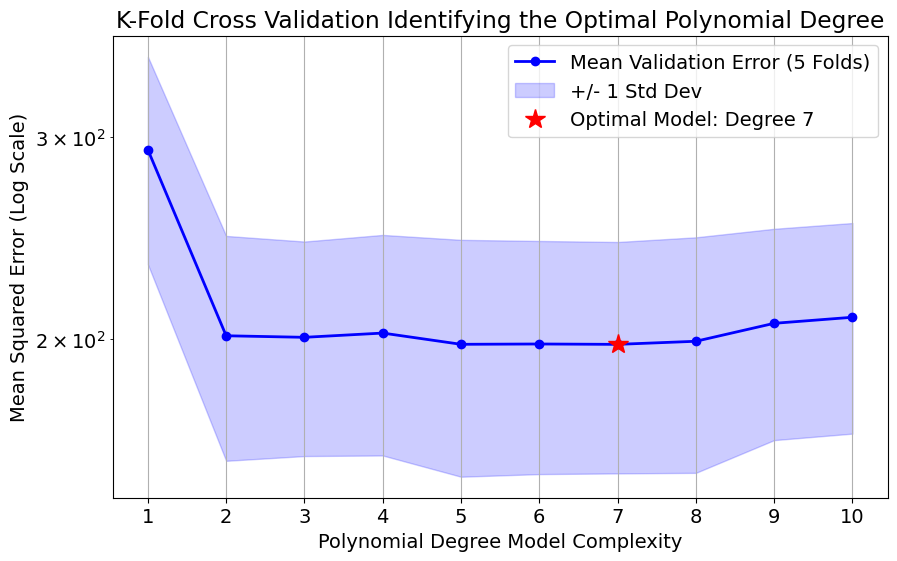


Conclusion: K-Fold CV correctly identified that a Degree 7 polynomial handles the underlying physics without overfitting to the sensor noise!


In [39]:
# Let's plot the average Cross-Validation error across our 10 potential models
plt.figure(figsize=(10, 6))

# Plot the mean error
plt.plot(degrees, cv_mean_errors, 'b-o', linewidth=2, label='Mean Validation Error (5 Folds)')

# Plot a shaded region representing the variance (+/- 1 standard deviation)
plt.fill_between(degrees,
                 cv_mean_errors - cv_std_errors,
                 cv_mean_errors + cv_std_errors,
                 color='blue', alpha=0.2, label='+/- 1 Std Dev')

# The optimal degree is the one with the minimum mean error
optimal_idx = np.argmin(cv_mean_errors)
optimal_degree = degrees[optimal_idx]

plt.plot(optimal_degree, cv_mean_errors[optimal_idx], 'r*', markersize=15,
         label=f'Optimal Model: Degree {optimal_degree}')

# Use a logarithmic scale because higher polynomials will explode the error (overfitting)
plt.yscale('log')
plt.xlabel('Polynomial Degree Model Complexity')
plt.ylabel('Mean Squared Error (Log Scale)')
plt.title('K-Fold Cross Validation Identifying the Optimal Polynomial Degree')
plt.legend()
plt.xticks(degrees)
plt.show()

print(f"\nConclusion: K-Fold CV correctly identified that a Degree {optimal_degree} polynomial handles the underlying physics without overfitting to the sensor noise!")

### Challenge Problem: Principal Component Regression (PCR)
Often in aerospace validation, we face highly collinear inputs (e.g. pressure sensors reading nearly the same thing). **Singular Value Decomposition (SVD) / Principal Component Analysis (PCA)** extracts the core underlying signals. Your challenge: Build a Scikit-Learn pipeline that sequences `StandardScaler`, `PCA` (keeping 95% variance), and `LinearRegression`. Run this pipeline through our K-Fold Cross Validation setup (even though our current synthetic 1D input won't benefit directly, this architecture is essential for N-dimensional datasets!).

In [40]:
# YOUR CODE HERE
# 1. Create a machine learning pipeline: make_pipeline(StandardScaler(), PCA(n_components=0.95), LinearRegression())
# 2. Run cross_val_score using the existing k_folds on X_features and y_target
# 3. Print the mean validation Mean Squared Error.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
# ...

<details>
<summary><b>Click to Reveal Solution</b></summary>

```python
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

# 1. Build an advanced pipeline
# PCR (Principal Component Regression) is StandardScaler -> PCA -> LinearRegression
pcr_pipeline = make_pipeline(StandardScaler(), PCA(n_components=0.95), LinearRegression())

# 2. Run Cross Validation
pcr_scores = cross_val_score(pcr_pipeline, X_features, y_target, cv=k_folds, scoring='neg_mean_squared_error')
mse_pcr_scores = -pcr_scores

# 3. Print Results
print(f"PCR Pipeline Mean Validation MSE: {np.mean(mse_pcr_scores):.2f}")
print(f"PCR Pipeline Std Dev MSE:       {np.std(mse_pcr_scores):.2f}")
print("\nFor this 1D input, PCR acts just like Linear Regression, but this architecture is scalable to 1,000s of collinear aerodynamic features!")
```
</details>